In [28]:
import io
import zipfile
import json
import pandas as pd
import matplotlib.pyplot as plt

In [31]:
zip_file_path = '../data/logs/round_1/155469.zip'

In [32]:
with zipfile.ZipFile(zip_file_path, 'r') as archive:
    files = archive.namelist()
    json_filename = [f for f in files if f[-4:]=='json']
    assert len(json_filename) == 1, "More than one json file in the log archive"
    json_filename = json_filename[0]
    
    with archive.open(json_filename) as json_file:
        data = json.load(json_file)
        activities = data['activitiesLog']
        df = pd.read_csv(io.StringIO(activities), sep=';')

In [41]:
pepper = df[df['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True)
osmium = df[df['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True)

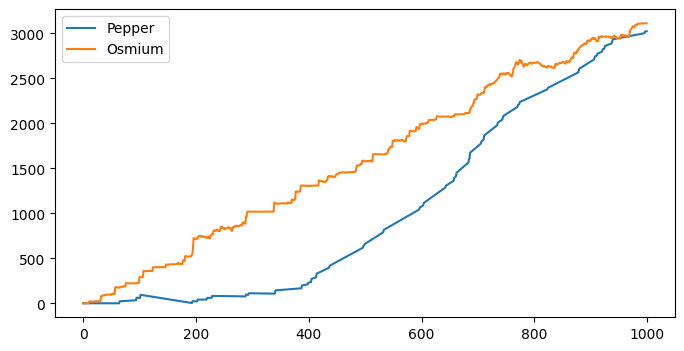

In [42]:
plt.figure(figsize=(8, 4))
plt.plot(pepper['profit_and_loss'], label='Pepper')
plt.plot(osmium['profit_and_loss'], label='Osmium')
plt.legend()
plt.show()

In [35]:
price = df.drop(columns=['day', 'profit_and_loss'])
price_pepper = price[price['product'] == 'INTARIAN_PEPPER_ROOT']
price_osmium = price[price['product'] == 'ASH_COATED_OSMIUM']
price_pepper_clean = price_pepper.dropna(subset=price_pepper.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)
price_osmium_clean = price_osmium.dropna(subset=price_osmium.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)

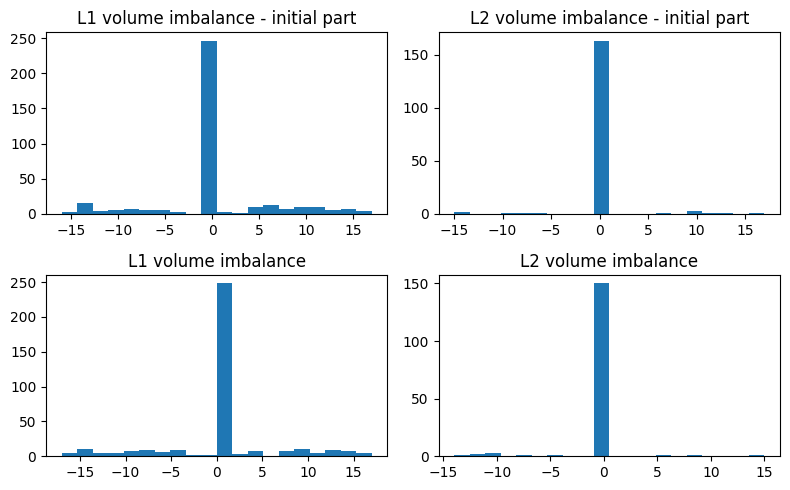

In [46]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].hist(price_pepper_clean.iloc[:400]['ask_volume_1'] - price_pepper_clean.iloc[:400]['bid_volume_1'], bins=20)
ax[0, 1].hist(price_pepper_clean.iloc[:400]['ask_volume_2'] - price_pepper_clean.iloc[:400]['bid_volume_2'], bins=20)
ax[1, 0].hist(price_pepper_clean.iloc[400:800]['ask_volume_1'] - price_pepper_clean.iloc[400:800]['bid_volume_1'], bins=20)
ax[1, 1].hist(price_pepper_clean.iloc[400:800]['ask_volume_2'] - price_pepper_clean.iloc[400:800]['bid_volume_2'], bins=20)
ax[0, 0].set_title('L1 volume imbalance - initial part')
ax[0, 1].set_title('L2 volume imbalance - initial part')
ax[1, 0].set_title('L1 volume imbalance')
ax[1, 1].set_title('L2 volume imbalance')
plt.tight_layout()
plt.show()